# Find edge projectors - circuit cluster states - Random FDLU - Sweep
Created 26/08/2026

Objectives:
* Iterate on [this notebook](find_edge_projectors_circuit_cluster_states_random_fdlu.ipynb), now sweeping over multiple random states.

# Package imports

In [1]:
import sys

In [2]:
from itertools import chain, combinations
from collections import defaultdict
import re

In [3]:
import h5py
from tenpy.tools import hdf5_io
import tenpy
import tenpy.linalg.np_conserved as npc

import os
import pickle

In [4]:
import numpy as np
import jax.numpy as jnp

import pandas as pd

import matplotlib.pyplot as plt
import matplotlib

In [5]:
import quimb as qu
import quimb.tensor as qtn
from quimb.tensor.optimize import TNOptimizer

/home/kcooney/Desktop/repos/spt_numerical_classificiation/code/num_spt_venv_p11/lib/python3.11/site-packages/cotengra/hyperoptimizers/hyper.py:54: UserWarning: Couldn't find `optuna`, `cmaes`, or `nevergrad` so will use completely random sampling in place of hyper-optimization.
  warnings.warn(
/home/kcooney/Desktop/repos/spt_numerical_classificiation/code/num_spt_venv_p11/lib/python3.11/site-packages/cotengra/hyperoptimizers/hyper.py:36: UserWarning: Couldn't import `kahypar` - skipping from default hyper optimizer and using basic `labels` method instead.
  warnings.warn(
/home/kcooney/Desktop/repos/spt_numerical_classificiation/code/num_spt_venv_p11/lib/python3.11/site-packages/cotengra/hyperoptimizers/hyper.py:73: UserWarning: Couldn't find `optuna`, `cmaes`, or `nevergrad` so will use completely random sampling in place of hyper-optimization.
  warnings.warn(


In [6]:
from quspin.operators import hamiltonian
from quspin.operators import quantum_operator
from quspin.basis import spin_basis_1d

In [7]:
from itertools import cycle

In [75]:
from tqdm import tqdm

# Definitions

## Construct cluster state

In [8]:
np_up_X_state = 1/(np.sqrt(2))*np.array([1,1])

In [9]:
qu_up_X_state = qtn.Tensor(
    data=np_up_X_state,
    inds=('k',),
    tags='prod'
)

In [10]:
np_CZ = np.diag([1,1,1,-1])

In [11]:
np_CZ = np_CZ.reshape((2,)*4)

In [12]:
qu_CZ = qtn.Tensor(
    data=np_CZ,
    inds=('k1', 'k2', 'b1', 'b2'),
    tags='CZ'
)

In [13]:
def get_cluster_state_qu_tensor_network(num_sites):
    assert (num_sites%2) == 0

    product_state_tensors = [
        qu_up_X_state.reindex({'k': f'kc_1_{i}'})
        for i in range(num_sites)
    ]

    first_layer_circuit_tensors = [
        qu_CZ.reindex({
            'b1': f'kc_1_{i}',
            'b2': f'kc_1_{i+1}',
            'k1': f'kc_2_{i}',
            'k2': f'kc_2_{i+1}'
        })
        for i in range(0, num_sites, 2)
    ]


    second_layer_circuit_tensors = [
        qu_CZ.reindex({
            'b1': f'kc_2_{i}',
            'b2': f'kc_2_{(i+1)%num_sites}',
            'k1': f'k{i}',
            'k2': f'k{(i+1)%num_sites}'
        })
        for i in range(1, num_sites+1, 2)
    ]

    all_tensors = (
        product_state_tensors
        + first_layer_circuit_tensors
        + second_layer_circuit_tensors
    )

    out = qtn.TensorNetwork(all_tensors, virtual=True)
    out.mangle_inner_()

    return out

## Apply random unitaries

In [14]:
np.power(2, -1/2)

0.7071067811865476

In [15]:
def generate_random_symmetry_respecting_unitary():
    theta = np.random.uniform(0, 2*np.pi, 4)
    diag_phases = np.diag(np.exp(1j * theta))

    np_H = np.power(2, -1/2)*np.array([
        [1,1],
        [1,-1]
    ])

    np_H_2_site = np.kron(np_H, np_H)

    u = (
        np_H_2_site
        @ diag_phases
        @ np_H_2_site
    )

    return u

In [16]:
u = generate_random_symmetry_respecting_unitary()

In [17]:
np.round(u @ u.conj().T, 3)

array([[ 1.+0.j, -0.+0.j,  0.-0.j,  0.+0.j],
       [-0.+0.j,  1.+0.j,  0.+0.j,  0.+0.j],
       [ 0.+0.j,  0.+0.j,  1.+0.j, -0.+0.j],
       [ 0.+0.j,  0.+0.j, -0.+0.j,  1.+0.j]])

In [18]:
np_X = np.array([[0,1],[1,0]])
np_I = np.array([[1,0],[0,1]])

In [19]:
np_X_1 = np.kron(np_X, np_I)
np_X_2 = np.kron(np_I, np_X)

In [20]:
np.linalg.norm(np_X_1 @ u - u @ np_X_1)

0.0

In [21]:
np.linalg.norm(np_X_2 @ u - u @ np_X_2)

0.0

So it is actually unitary.

In [22]:
# Warning, likely making assupmtions about shape of psi, number of sites being even here etc.
def apply_haar_random_fdlu_to_quimb_state(psi, domains_dict):
    num_sites = domains_dict['num_system_sites']

    depth = domains_dict['fdlu_depth']
    offset = domains_dict['fdlu_offset']

    all_circuit_lists = [
        list() for _ in range(depth)
    ]

    for layer, circuit_list in enumerate(all_circuit_lists):
        delta = layer
    
        for i in range(num_sites//2):
            site_1 = ((2*i)+delta+offset)%num_sites
            site_2 = ((2*i)+1+delta+offset)%num_sites

            u = generate_random_symmetry_respecting_unitary()

            inds=[
                f'k_{layer+1}_{site_1}',
                f'k_{layer+1}_{site_2}',
                f'k_{layer}_{site_1}',
                f'k_{layer}_{site_2}'
            ]
            
            qu_u = qtn.Tensor(
                u.reshape((2,)*4),
                inds=inds,
                tags=f'Layer_{layer}'
            )

            circuit_list.append(qu_u)

    all_tensors = (
        [psi.reindex({f'k{i}': f'k_0_{i}' for i in range(num_sites)})]
        + sum(all_circuit_lists, start=[])
    )

    out = (
        qtn
        .TensorNetwork(all_tensors, virtual=False)
        .mangle_inner_()
        .reindex({f'k_{depth}_{i}': f'k{i}' for i in range(num_sites)}) 
    )

    return out

## Symmetries and effective density matrices

In [23]:
np_I = np.array([[1,0],[0,1]])
np_X = np.array([[0,1],[1,0]])
np_Z = np.array([[1,0],[0,-1]])

In [24]:
qu_I = qtn.Tensor(np_I, inds=['k', 'b'])
qu_X = qtn.Tensor(np_X, inds=['k', 'b'])
qu_Z = qtn.Tensor(np_Z, inds=['k', 'b'])

In [25]:
symmetry_actions = [
    [qu_I, qu_I],
    [qu_I, qu_X],
    [qu_X, qu_I],
    [qu_X, qu_X]
]

In [26]:
symmetry_labels = [
    'II',
    'IX',
    'XI',
    'XX'
]

In [27]:
def generate_edm(cut_psi, sites, symmetry_pair, num_defect_sites):
    assert 2*num_defect_sites < len(sites)

    left_defect_sites = sites[:num_defect_sites]
    right_defect_sites = sites[-num_defect_sites:]
    internal_sites = sites[num_defect_sites:-num_defect_sites]

    # Being sloppy with the gate indices as the symmetries are invariant
    # under transpose and conjugation.
    left_sym_gates = [
        symmetry_pair[i%2].reindex({'k': f'b{i}', 'b': f'c{i}'})
        for i in left_defect_sites
    ]

    inner_gates = [
        symmetry_pair[i%2].reindex({'k': f'k{i}', 'b': f'b{i}'})
        for i in internal_sites
    ]

    right_sym_gates = [
        symmetry_pair[i%2].reindex({'k': f'b{i}', 'b': f'c{i}'})
        for i in right_defect_sites
    ]

    psi_bra_reindex_map = (
        {f'k{i}': f'c{i}' for i in left_defect_sites + right_defect_sites}
        | {f'k{i}': f'b{i}' for i in internal_sites}
    )

    edm = (
        cut_psi
        & left_sym_gates
        & inner_gates
        & right_sym_gates
        & cut_psi.conj().reindex(psi_bra_reindex_map)
    )

    edm = edm.contract()

    fuse_maps = [
        ('k_left', (f'k{i}' for i in left_defect_sites)),
        ('b_left', (f'b{i}' for i in left_defect_sites)),
        ('k_right', (f'k{i}' for i in right_defect_sites)),
        ('b_right', (f'b{i}' for i in right_defect_sites))
    ]

    edm.fuse(fuse_maps, inplace=True)

    return edm

## SPT extraction functions

In [28]:
symmetry_combination_labels = list(combinations(symmetry_labels, 2))

In [29]:
e, a, b, c = symmetry_labels

In [30]:
group_products = [
    (a, b, c),
    (b, a, c),
    (a, c, b),
    (c, a, b),
    (c, b, a),
    (b, c, a)
]

In [31]:
def get_proj_rep_phase(cut_rho, r_g, r_h, r_gh, u_g, left_right):
    k_ind = f'k_{left_right}'
    b_ind = f'b_{left_right}'

    invariant_tn = (
        cut_rho
        & r_g.reindex({b_ind: 'i1'})
        & u_g.conj().reindex({k_ind: 'i1', b_ind: 'i2'})
        & r_h.reindex({k_ind: 'i2', b_ind: 'i3'})
        & u_g.reindex({b_ind: 'i3', k_ind: 'i4'})
        & r_gh.conj().reindex({b_ind: 'i4', k_ind: b_ind})
    )

    out = invariant_tn.contract()

    return out

In [32]:
def get_defect_symmetry_gate(symmetry_label, defect_sites, left_right):
    sym_pair = next(
        pair for label, pair in zip(symmetry_labels, symmetry_actions)
        if label == symmetry_label
    )

    sym_gates = [
        sym_pair[i%2].reindex({'k': f'k{i}', 'b': f'b{i}'})
        for i in defect_sites
    ]

    fuse_map = [
        (f'k_{left_right}', (f'k{i}' for i in defect_sites)),
        (f'b_{left_right}', (f'b{i}' for i in defect_sites))
    ]
   
    gate = (
        qtn
        .TensorNetwork(sym_gates)
        .contract()
        .fuse(fuse_map)
    )

    return gate

In [33]:
def get_proj_rep_phases(rho, unitaries, left_right, defect_sites):
    out = list()

    unitaries_dict = {
        k: v for k, v in zip(symmetry_labels[1:], unitaries)
    }

    out_phases = list()
    for a, b, c in group_products:
        sym_gate = get_defect_symmetry_gate(
            a, defect_sites, left_right
        )

        phase = get_proj_rep_phase(
            rho,
            unitaries_dict[a],
            unitaries_dict[b],
            unitaries_dict[c],
            sym_gate,
            left_right
        )

        out_phases.append(phase)

    return out_phases

## Optimisation functions

In [34]:
def solve_for_boundary_operators(edm, num_iters=20):
    # Careful, the indices are reversed here for ease.
    # i.e. the k, b indices have been swapped to make tensor contraction easier.
    scores = list()

    u_left = qtn.tensor_builder.rand_tensor(
        (edm.ind_size('b_left'), edm.ind_size('k_left')),
        inds=['k_left', 'b_left'],
        dtype='complex64'
    )

    u_right = qtn.tensor_builder.rand_tensor(
        (edm.ind_size('b_right'), edm.ind_size('k_right')),
        inds=['k_right', 'b_right'],
        dtype='complex64'
    )

    for _ in range(num_iters):
        right_edm = (edm & u_left).contract()
        data = right_edm.data
        U, S, VH = np.linalg.svd(data)
        scores.append(np.sum(S))
    
        sol = (U @ VH).conj().T
        u_right = qtn.Tensor(sol, inds = ['b_right', 'k_right'])
        
        left_edm = (edm & u_right).contract()
        data = left_edm.data
        U, S, VH = np.linalg.svd(data)
        scores.append(np.sum(S))
    
        sol = (U @ VH).conj().T
        u_left = qtn.Tensor(sol, inds = ['b_left', 'k_left'])

    return (u_left, u_right), scores

## Extracting projectors

In [35]:
def random_uniform_complex(shape):
    return np.random.uniform(size=shape) + 1j*np.random.uniform(size=shape)

In [36]:
def lanczos_iteration(rho, v, sites):
    w = (
        rho & v.reindex({f'k{i}': f'b{i}' for i in sites})
    ).contract()

    w_norm = np.sqrt((w & w.conj()).contract())

    out = w/w_norm

    return out

In [37]:
def lanczos_algorithm(rho, v, sites, num_iters=20):
    for _ in range(num_iters):
        v = lanczos_iteration(rho, v, sites)

    return v

In [38]:
def maximize_projector_states(rho):
    # Assume's rho is a single tensor, not a tensor network.
    k_inds = [i for i in rho.outer_inds() if i.startswith('k')]
    #b_inds = [i for i in rho.inds if i.startswith('b')]

    sites = [int(s[1:]) for s in k_inds]

    v = qtn.Tensor(
        data=random_uniform_complex((2,)*len(sites)),
        inds=[f'k{i}' for i in sites]
    )

    v = lanczos_algorithm(
        rho,
        v,
        sites,
        num_iters=20
    )

    new_v = lanczos_iteration(rho, v, sites)

    overlap = np.abs((v & new_v.conj()).contract())

    score = (
        v.reindex({f'k{i}': f'b{i}' for i in sites})
        & rho
        & v.conj()
    )
    score = score.contract()


    return score, v, overlap

In [39]:
def projector_state_check(state, rho, left_sites):
    left_right_rho = (
        rho
        & state
        & state.conj().reindex({s: f'b{s[1:]}' for s in state.inds})
    )

    left_right_rho = left_right_rho.contract()

    left_inds = [
        f'{s}{i}'
        for i in left_sites
        for s in 'kb'
    ]

    schmidt_decomp = qtn.tensor_core.tensor_split(
        left_right_rho,
        left_inds=left_inds,
        method='svd',
        #cutoff=1e-6,
        cutoff_mode='abs',
        absorb=None,
        renorm=False,
        bond_ind='v'
    )

    schmidt_vals = schmidt_decomp.tensors[1]

    return schmidt_vals

## Extract cut rho and EDM

In [40]:
def generate_edm_from_cut_state(cut_state, sites, symmetry_pair, num_defect_sites):
    # Lots of duplicate code, probably a better way to do this.
    assert 2*num_defect_sites < len(sites)

    left_defect_sites = sites[:num_defect_sites]
    right_defect_sites = sites[-num_defect_sites:]
    internal_sites = sites[num_defect_sites:-num_defect_sites]

    # Being sloppy with the gate indices as the symmetries are invariant
    # under transpose and conjugation.
    left_sym_gates = [
        symmetry_pair[i%2].reindex({'k': f'b{i}', 'b': f'c{i}'})
        for i in left_defect_sites
    ]

    inner_gates = [
        symmetry_pair[i%2].reindex({'k': f'k{i}', 'b': f'b{i}'})
        for i in internal_sites
    ]

    right_sym_gates = [
        symmetry_pair[i%2].reindex({'k': f'b{i}', 'b': f'c{i}'})
        for i in right_defect_sites
    ]

    reindex_map = (
        {
            f'k{i}': f'c{i}'
            for i in (left_defect_sites + right_defect_sites)
        }
        |
        {
            f'k{i}': f'b{i}'
            for i in internal_sites
        }
    )

    edm = (
        cut_state
        & cut_state.conj().reindex(reindex_map)
        & left_sym_gates
        & inner_gates
        & right_sym_gates
    )

    edm = edm.contract()

    fuse_maps = [
        ('k_left', (f'k{i}' for i in left_defect_sites)),
        ('b_left', (f'b{i}' for i in left_defect_sites)),
        ('k_right', (f'k{i}' for i in right_defect_sites)),
        ('b_right', (f'b{i}' for i in right_defect_sites))
    ]

    edm.fuse(fuse_maps, inplace=True)

    return edm

## SPT extraction functions

In [41]:
symmetry_combination_labels = list(combinations(symmetry_labels, 2))

In [42]:
symmetry_combination_labels

[('II', 'IX'),
 ('II', 'XI'),
 ('II', 'XX'),
 ('IX', 'XI'),
 ('IX', 'XX'),
 ('XI', 'XX')]

In [43]:
e, a, b, c = symmetry_labels

In [44]:
group_products = [
    (a, b, c),
    (b, a, c),
    (a, c, b),
    (c, a, b),
    (c, b, a),
    (b, c, a)
]

In [45]:
def get_proj_rep_phase(cut_rho, r_g, r_h, r_gh, u_g, left_right):
    k_ind = f'k_{left_right}'
    b_ind = f'b_{left_right}'

    invariant_tn = (
        cut_rho
        & r_g.reindex({b_ind: 'i1'})
        & u_g.conj().reindex({k_ind: 'i1', b_ind: 'i2'})
        & r_h.reindex({k_ind: 'i2', b_ind: 'i3'})
        & u_g.reindex({b_ind: 'i3', k_ind: 'i4'})
        & r_gh.conj().reindex({b_ind: 'i4', k_ind: b_ind})
    )

    out = invariant_tn.contract()

    return out

In [46]:
def get_defect_symmetry_gate(symmetry_label, defect_sites, left_right):
    sym_pair = next(
        pair for label, pair in zip(symmetry_labels, symmetry_actions)
        if label == symmetry_label
    )

    sym_gates = [
        sym_pair[i%2].reindex({'k': f'k{i}', 'b': f'b{i}'})
        for i in defect_sites
    ]

    fuse_map = [
        (f'k_{left_right}', (f'k{i}' for i in defect_sites)),
        (f'b_{left_right}', (f'b{i}' for i in defect_sites))
    ]
   
    gate = (
        qtn
        .TensorNetwork(sym_gates)
        .contract()
        .fuse(fuse_map)
    )

    return gate

In [47]:
def get_proj_rep_phases(rho, unitaries, left_right, defect_sites):
    out = list()

    unitaries_dict = {
        k: v for k, v in zip(symmetry_labels[1:], unitaries)
    }

    out_phases = list()
    for a, b, c in group_products:
        sym_gate = get_defect_symmetry_gate(
            a, defect_sites, left_right
        )

        phase = get_proj_rep_phase(
            rho,
            unitaries_dict[a],
            unitaries_dict[b],
            unitaries_dict[c],
            sym_gate,
            left_right
        )

        out_phases.append(phase)

    return out_phases

## Sweep function

In [55]:
def extract_projector(psi, rho_sites, num_pad_sites):
    rho = (psi & psi.conj().reindex({f'k{i}': f'b{i}' for i in rho_sites}))
    score, proj_vec, overlap = maximize_projector_states(rho)

    larger_sites = list(range(
        min(rho_sites) - num_pad_sites,
        max(rho_sites)  + num_pad_sites
    ))

    larger_rho = (psi & psi.conj().reindex({f'k{i}': f'b{i}' for i in larger_sites}))

    """
    print(proj_vec)
    print()
    print(larger_rho)
    print()
    print(list(range(min(rho_sites) - num_pad_sites, min(rho_sites))))
    print()
    print(min(rho_sites))
    print(num_pad_sites)
    """

    schmidt_vals = projector_state_check(
        proj_vec,
        larger_rho,
        list(range(min(rho_sites) - num_pad_sites, min(rho_sites)))
    )

    return proj_vec, score, overlap, schmidt_vals

In [73]:
def find_invariants_via_projectors_from_random_state(psi, domains_dict):
    rand_psi = apply_haar_random_fdlu_to_quimb_state(psi, domains_dict)

    left_proj_vec, *left_proj_vec_results = extract_projector(
        rand_psi,
        domains_dict['left_projector_sites'],
        domains_dict['num_projector_pad_sites']
    )

    right_proj_vec, *right_proj_vec_results = extract_projector(
        rand_psi,
        domains_dict['right_projector_sites'],
        domains_dict['num_projector_pad_sites']
    )

    cut_sites = list(range(
        min(domains_dict['left_projector_sites']),
        max(domains_dict['right_projector_sites'])+1
    ))

    cut_rho_unprojected = (
        psi
        & psi.conj().reindex({f'k{i}': f'b{i}' for i in cut_sites})
    )

    left_proj_sites = domains_dict['left_projector_sites']
    right_proj_sites = domains_dict['right_projector_sites']

    cut_rho = (
        cut_rho_unprojected.reindex({
            **{f'k{i}': f'l{i}' for i in left_proj_sites},
            **{f'k{i}': f'l{i}' for i in right_proj_sites},
            **{f'b{i}': f'c{i}' for i in left_proj_sites},
            **{f'b{i}': f'c{i}' for i in right_proj_sites}
        })
        & left_proj_vec.conj().reindex({f'k{i}': f'l{i}' for i in left_proj_sites})
        & left_proj_vec
        & left_proj_vec.reindex({f'k{i}': f'c{i}' for i in left_proj_sites})
        & left_proj_vec.conj().reindex({f'k{i}': f'b{i}' for i in left_proj_sites})
        & right_proj_vec.conj().reindex({f'k{i}': f'l{i}' for i in right_proj_sites})
        & right_proj_vec
        & right_proj_vec.reindex({f'k{i}': f'c{i}' for i in right_proj_sites})
        & right_proj_vec.conj().reindex({f'k{i}': f'b{i}' for i in right_proj_sites})
    )

    cut_rho_trace = (
        cut_rho
        .reindex({f'b{i}': f'k{i}' for i in cut_sites})
        .contract()
    )

    cut_rho = cut_rho/cut_rho_trace

    tranpose_map = (
        {f'k{i}': f'b{i}' for i in cut_sites}
        | {f'b{i}': f'k{i}' for i in cut_sites}
    )

    cut_rho_purity = (
        (cut_rho & cut_rho.reindex(tranpose_map))
        .contract()
    )

    sub_cut_sites = list(range(
        max(domains_dict['left_projector_sites'])+1,
        min(domains_dict['right_projector_sites'])
    ))

    sub_cut_rho = (
        cut_rho
        .reindex({f'k{i}': f'b{i}' for i in left_proj_sites + right_proj_sites})
    )

    sub_cut_rho_trace = (
        sub_cut_rho
        .reindex({f'b{i}': f'k{i}' for i in sub_cut_sites})
        .contract()
    )

    tranpose_map = (
        {f'k{i}': f'b{i}' for i in sub_cut_sites}
        | {f'b{i}': f'k{i}' for i in sub_cut_sites}
    )

    sub_cut_rho_purity = (
        (sub_cut_rho & sub_cut_rho.reindex(tranpose_map))
        .contract()
    )

    cut_score, cut_state, cut_overlap = maximize_projector_states(sub_cut_rho)

    edms = [
        generate_edm_from_cut_state(
            cut_state,
            sub_cut_sites,
            s,
            domains_dict['num_defect_sites']
        )
        for s in symmetry_actions[1:]
    ]

    defect_ops_results = [
        solve_for_boundary_operators(edm, num_iters=20)
        for edm in edms
    ]

    left_defect_sites = list(range(
        max(domains_dict['left_projector_sites']) + 1,
        max(domains_dict['left_projector_sites']) + 1 + domains_dict['num_defect_sites']
    ))
    right_defect_sites = list(range(
        min(domains_dict['right_projector_sites']) - domains_dict['num_defect_sites'],
        min(domains_dict['right_projector_sites'])
    ))

    left_rdm = (
        cut_rho
        .reindex({
            f'b{i}': f'k{i}'
            for i in cut_sites if i not in left_defect_sites
        })
    )
    left_rdm = left_rdm.contract()
    left_fuse_map = [
        ('k_left', [f'k{i}' for i in left_defect_sites]),
        ('b_left', [f'b{i}' for i in left_defect_sites])
    ]
    left_rdm.fuse(left_fuse_map, inplace=True)
    
    right_rdm = (
        cut_rho
        .reindex({
            f'b{i}': f'k{i}'
            for i in cut_sites if i not in right_defect_sites
        })
    )
    right_rdm = right_rdm.contract()
    right_fuse_map = [
        ('k_right', [f'k{i}' for i in right_defect_sites]),
        ('b_right', [f'b{i}' for i in right_defect_sites])
    ]
    right_rdm.fuse(right_fuse_map, inplace=True)

    unitary_pairs = [l[0] for l in defect_ops_results]
    left_unitaries, right_unitaries = zip(*unitary_pairs)

    left_phases = np.array(get_proj_rep_phases(
        left_rdm,
        left_unitaries,
        'left',
        left_defect_sites
    ))

    right_phases = np.array(get_proj_rep_phases(
        right_rdm,
        right_unitaries,
        'right',
        right_defect_sites
    ))

    out = {
        'left_proj_vec': left_proj_vec,
        'left_proj_vec_results': left_proj_vec_results,
        'right_proj_vec': right_proj_vec,
        'right_proj_vec_results': right_proj_vec_results,
        'cut_rho_purity': cut_rho_purity,
        'sub_cut_rho_trace': sub_cut_rho_trace,
        'sub_cut_rho_purity': sub_cut_rho_purity,
        'cut_score': cut_score,
        'cut_state': cut_state,
        'cut_overlap': cut_overlap,
        'defect_ops_scores': [l[1] for l in defect_ops_results],
        'left_phases': left_phases,
        'right_phases': right_phases
    }

    return out

# Sweep
## Depth 1

In [90]:
domains_dict = {
    'num_system_sites': 32,
    'left_projector_sites': list(range(4, 10)),
    'right_projector_sites': list(range(22, 28)),
    'num_projector_pad_sites': 2,
    'num_defect_sites': 4,
    'fdlu_depth': 1,
    'fdlu_offset': 0
}

In [91]:
psi = get_cluster_state_qu_tensor_network(domains_dict['num_system_sites'])

In [92]:
results = list()

for _ in tqdm(range(20)):
    current = find_invariants_via_projectors_from_random_state(psi, domains_dict)
    results.append(current)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:08<00:00,  2.37it/s]


### Analyze results

#### Projector scores

In [103]:
[
    d['left_proj_vec_results'][0]
    for d in results
]

[(0.2500000000000018-1.5944832215726802e-18j),
 (0.2500000000000016+6.254287761888652e-18j),
 (0.2500000000000019-1.1208283627835579e-17j),
 (0.2500000000000019-1.836080787240344e-18j),
 (0.25000000000000183+2.0896686684272927e-17j),
 (0.25000000000000183-1.4387386221452807e-17j),
 (0.2500000000000018-1.2822778755550253e-17j),
 (0.25000000000000155+1.8799577342692718e-17j),
 (0.2500000000000018+2.4153936122540217e-17j),
 (0.2500000000000018+5.58773796215384e-19j),
 (0.2500000000000017+2.400319034277578e-17j),
 (0.2500000000000018-4.90913586075718e-18j),
 (0.2500000000000016+2.916306809203999e-18j),
 (0.2500000000000018+9.16532508209174e-19j),
 (0.2500000000000019+8.723327025389687e-18j),
 (0.25000000000000183+1.7315959741984155e-17j),
 (0.2500000000000018-1.1061359421481478e-17j),
 (0.250000000000002+6.017766218183109e-18j),
 (0.2500000000000019-1.2612933029042647e-17j),
 (0.2500000000000017-2.77439641632905e-17j)]

In [104]:
[
    d['right_proj_vec_results'][0]
    for d in results
]

[(0.25000000000000194-1.3877787807814457e-17j),
 (0.25000000000000183-2.7755575615628914e-17j),
 (0.2500000000000018+2.0816681711721685e-17j),
 (0.250000000000002+1.3877787807814457e-17j),
 (0.2500000000000019-6.938893903907228e-18j),
 (0.2500000000000019+0j),
 (0.2500000000000019+6.938893903907228e-18j),
 (0.2500000000000017+2.7755575615628914e-17j),
 (0.2500000000000018+8.673617379884035e-18j),
 (0.25000000000000183-6.938893903907228e-18j),
 (0.2500000000000019+0j),
 (0.2500000000000017+0j),
 (0.2500000000000018-1.3877787807814457e-17j),
 (0.2500000000000018+0j),
 (0.2500000000000019-1.734723475976807e-17j),
 (0.2500000000000019+0j),
 (0.2500000000000019+1.734723475976807e-18j),
 (0.25000000000000194-1.734723475976807e-17j),
 (0.2500000000000018-1.3877787807814457e-17j),
 (0.2500000000000018+6.938893903907228e-18j)]

In [106]:
[
    d['left_proj_vec_results'][1]
    for d in results
]

[0.9999999999999999,
 0.9999999999999999,
 1.0000000000000002,
 1.0,
 0.9999999999999999,
 1.0,
 1.0,
 0.9999999999999998,
 1.0,
 1.0,
 0.9999999999999999,
 1.0,
 1.0,
 1.0,
 1.0000000000000002,
 1.0,
 1.0000000000000002,
 1.0,
 1.0000000000000002,
 1.0]

In [105]:
[
    d['right_proj_vec_results'][1]
    for d in results
]

[1.0,
 1.0,
 1.0,
 1.0,
 1.0000000000000002,
 1.0,
 1.0000000000000002,
 1.0000000000000002,
 1.0,
 0.9999999999999999,
 1.0000000000000002,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 0.9999999999999998]

In [109]:
def get_schmidt_vals_ratio(schmidt_vals):
    return schmidt_vals.data[1]/schmidt_vals.data[0]

In [110]:
[
    get_schmidt_vals_ratio(d['left_proj_vec_results'][2])
    for d in results
]

[0.7266273600131448,
 0.20025845375801715,
 0.7337574705553506,
 0.6981942962600416,
 0.24995412316934978,
 0.15410173193491875,
 0.6416719848154212,
 0.37507238331090775,
 0.1469852152457774,
 0.2086826801902379,
 0.6091343063681627,
 0.8000871315639515,
 0.4913642883740856,
 0.5845757585800521,
 0.23609254968207408,
 0.3477034787241659,
 0.08046149941495805,
 0.019245518859837524,
 0.021874862505542967,
 0.042552745485031226]

In [111]:
[
    get_schmidt_vals_ratio(d['right_proj_vec_results'][2])
    for d in results
]

[0.6360503482947831,
 0.30148118047659644,
 0.39217736224277994,
 0.19668214657454305,
 0.04464777710032725,
 0.5601824805089932,
 0.34184673971454166,
 0.3448169959992956,
 0.015264829765641884,
 0.48780939562685777,
 0.018470592129631945,
 0.05695163132794728,
 0.10363278822458485,
 0.30555294564156227,
 0.3716966142252964,
 0.3731747015965471,
 0.6812364204798437,
 0.25109034487805654,
 0.21404994565786506,
 0.3463436285494079]

Still quite entangled in places.

#### Purities

In [112]:
[d['cut_rho_purity'] for d in results]

[(0.35900763598030594-3.915430644097534e-17j),
 (0.3606989979640496+1.5013746382633124e-16j),
 (0.4134116136298569+1.2448237638528613e-18j),
 (0.34833136757581173+2.2367980293976936e-17j),
 (0.4127543011974205+1.0846865936822369e-17j),
 (0.2871795414119812-5.322277762792798e-17j),
 (0.6717637735619231+1.9691963583700042e-16j),
 (0.5395593545001506-3.0519936372891057e-17j),
 (0.3631909586531098+9.089107061695236e-17j),
 (0.48050536905330365+1.5877062544421994e-17j),
 (0.44102318257489+1.0109333595346727e-16j),
 (0.4464638456836258-3.420373551840596e-17j),
 (0.503201538320981+1.5799752411786733e-17j),
 (0.7014354166066713+5.262709052346079e-16j),
 (0.3211932076947866-8.377805526071858e-20j),
 (0.49935716651340534+4.3231846110100525e-17j),
 (0.727243997562675-3.994762772709191e-17j),
 (0.3251310805279761-9.64514409434295e-19j),
 (0.3331706945489108-4.2569249948516996e-17j),
 (0.6325291683227774-1.4053139710933447e-16j)]

In [113]:
[d['sub_cut_rho_trace'] for d in results]

[(1.0000000000000009-5.834617715048411e-17j),
 (1.0000000000000009+2.501367204919327e-16j),
 (1.0000000000000004-6.668938957842675e-18j),
 (0.9999999999999998+3.7654704274102795e-17j),
 (0.9999999999999991+1.570956896643586e-17j),
 (1-8.02055150199384e-17j),
 (1+1.3939663015781162e-16j),
 (1.0000000000000002+5.841595622075589e-18j),
 (1.0000000000000004+8.521493815278683e-17j),
 (1.0000000000000007-1.2329227011814985e-17j),
 (1.0000000000000002+8.952695951269385e-17j),
 (0.9999999999999991-3.268293818910022e-17j),
 (1.0000000000000002+3.389816692622048e-17j),
 (1+3.6395703375328654e-16j),
 (1.0000000000000004+2.1610305802987628e-17j),
 (1.0000000000000004+7.183433548936926e-17j),
 (0.9999999999999998-8.679665630936815e-18j),
 (1.0000000000000002+2.7567360618381088e-17j),
 (1.0000000000000004-7.703301361433583e-17j),
 (0.9999999999999998-6.953775346353721e-17j)]

In [114]:
[d['sub_cut_rho_purity'] for d in results]

[(0.35900763598030594-3.915430644097534e-17j),
 (0.3606989979640496+1.5013746382633124e-16j),
 (0.4134116136298569+1.2448237638528613e-18j),
 (0.34833136757581173+2.2367980293976936e-17j),
 (0.4127543011974205+1.0846865936822369e-17j),
 (0.2871795414119812-5.322277762792798e-17j),
 (0.6717637735619231+1.9691963583700042e-16j),
 (0.5395593545001506-3.0519936372891057e-17j),
 (0.3631909586531098+9.089107061695236e-17j),
 (0.48050536905330365+1.5877062544421994e-17j),
 (0.44102318257489+1.0109333595346727e-16j),
 (0.4464638456836258-3.420373551840596e-17j),
 (0.503201538320981+1.5799752411786733e-17j),
 (0.7014354166066713+5.262709052346079e-16j),
 (0.3211932076947866-8.377805526071858e-20j),
 (0.49935716651340534+4.3231846110100525e-17j),
 (0.727243997562675-3.994762772709191e-17j),
 (0.3251310805279761-9.64514409434295e-19j),
 (0.3331706945489108-4.2569249948516996e-17j),
 (0.6325291683227774-1.4053139710933447e-16j)]

Purities are the same, which one could likely prove.

#### Cut state results

In [115]:
[d['cut_score'] for d in results]

[(0.48901413023883594-7.587758168119788e-17j),
 (0.5241537015221572+1.5091483697175373e-16j),
 (0.49253793064979345-3.356137197506178e-17j),
 (0.4869806503333747+6.228103010584588e-17j),
 (0.5411610993447014+2.4835541793738446e-19j),
 (0.39955482137607634-5.887298819508417e-17j),
 (0.797916240603887+1.4586690908749085e-16j),
 (0.689196433575018+6.943324945164615e-17j),
 (0.5158281419591465+4.831061412620258e-17j),
 (0.6518214306027438+8.951677148044838e-17j),
 (0.6162640224224051+4.448234536399751e-17j),
 (0.6147807268780274-7.945257501467138e-18j),
 (0.6367495713097999-5.324650946926448e-17j),
 (0.8278033634265046+3.0320698803161484e-16j),
 (0.45636344174378407+3.2217847638175085e-17j),
 (0.6091336280486592-3.01943611839807e-17j),
 (0.8463377515997488-3.174040793370266e-17j),
 (0.45325363245466227+3.181536580161251e-18j),
 (0.47807644531380705+5.225667033830168e-18j),
 (0.7810045145489075-9.979950426464037e-17j)]

In [116]:
[d['cut_overlap'] for d in results]

[0.9999999992203522,
 1.0000000000000027,
 0.999997599054755,
 0.9999999997077096,
 0.9999999999876585,
 0.9999999997303287,
 0.999999999999996,
 0.9999999999999957,
 0.9999999999998391,
 0.9999999999999983,
 1.0000000000000022,
 1.0000000000000016,
 0.9999999999999841,
 1.0000000000000007,
 0.9999999999736946,
 0.9999999999497752,
 0.9999999999999963,
 0.9999999978856041,
 0.9999999999995992,
 1.0000000000000049]

#### Defect op scores overlaps

In [118]:
np.round(np.array([[l[-1] for l in d['defect_ops_scores']] for d in results]), 5)

array([[1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.]])

#### Phases

In [93]:
left_phases = np.array([
    d['left_phases'] for d in results
])

In [94]:
left_phases.shape

(20, 6)

In [95]:
invariant_left_phases = left_phases[:, ::2]/left_phases[:, 1::2]

In [96]:
np.round(invariant_left_phases, 3)

array([[-0.863+0.03j , -0.883+0.141j, -1.043-0.086j],
       [-0.981-0.053j, -1.037-0.024j, -0.955-0.047j],
       [-1.019-0.115j, -0.992-0.028j, -0.943+0.076j],
       [-0.923+0.026j, -1.147-0.014j, -0.929-0.024j],
       [-1.06 -0.032j, -1.021+0.015j, -0.978-0.02j ],
       [-1.006-0.022j, -0.98 -0.013j, -1.134+0.155j],
       [-1.001+0.002j, -1.004+0.001j, -1.001-0.002j],
       [-1.01 -0.006j, -0.998-0.001j, -0.989+0.015j],
       [-1.062+0.036j, -1.011+0.085j, -1.056+0.033j],
       [-0.995-0.03j , -0.979-0.002j, -1.002+0.05j ],
       [-1.087+0.034j, -1.017-0.043j, -1.033+0.041j],
       [-1.028+0.05j , -0.978+0.08j , -1.021-0.012j],
       [-0.997-0.01j , -1.023+0.014j, -1.   +0.012j],
       [-1.015+0.04j , -1.   -0.024j, -0.999-0.002j],
       [-1.001+0.01j , -0.99 -0.009j, -1.001+0.017j],
       [-0.961-0.078j, -0.967-0.064j, -0.935+0.071j],
       [-1.011-0.007j, -1.004-0.01j , -1.005-0.003j],
       [-0.995-0.232j, -0.903+0.036j, -0.934-0.051j],
       [-0.892+0.226j, -1.02

In [97]:
right_phases = np.array([
    d['right_phases'] for d in results
])

In [98]:
right_phases.shape

(20, 6)

In [99]:
invariant_right_phases = right_phases[:, ::2]/right_phases[:, 1::2]

In [100]:
np.round(invariant_right_phases, 3)

array([[-0.988-0.043j, -1.035+0.027j, -0.944+0.057j],
       [-1.044+0.035j, -1.064+0.001j, -0.991+0.006j],
       [-1.022-0.043j, -0.99 +0.041j, -1.037+0.005j],
       [-1.01 -0.1j  , -0.902-0.046j, -0.999-0.063j],
       [-1.203-0.032j, -1.193-0.076j, -0.986+0.004j],
       [-0.967+0.079j, -1.159-0.003j, -0.984-0.264j],
       [-0.963-0.096j, -0.959-0.034j, -0.926-0.034j],
       [-1.012+0.01j , -1.013-0.014j, -0.988+0.007j],
       [-0.976+0.001j, -0.889-0.091j, -1.   -0.024j],
       [-1.017-0.026j, -1.052+0.017j, -0.999+0.009j],
       [-1.008+0.016j, -1.003-0.025j, -0.999+0.007j],
       [-0.995+0.j   , -1.002-0.011j, -0.996-0.022j],
       [-0.903-0.073j, -0.939+0.024j, -1.013+0.135j],
       [-0.998-0.001j, -1.002-0.j   , -0.997-0.j   ],
       [-1.29 -0.187j, -1.019-0.082j, -1.187-0.059j],
       [-1.   +0.001j, -1.   -0.002j, -1.001-0.009j],
       [-1.007-0.01j , -0.986-0.009j, -0.999+0.014j],
       [-1.145+0.144j, -1.058+0.072j, -1.08 +0.065j],
       [-0.988-0.078j, -0.99

## Depth 2

In [122]:
domains_dict = {
    'num_system_sites': 32,
    'left_projector_sites': list(range(4, 10)),
    'right_projector_sites': list(range(22, 28)),
    'num_projector_pad_sites': 2,
    'num_defect_sites': 4,
    'fdlu_depth': 2,
    'fdlu_offset': 0
}

In [123]:
results = list()

for _ in tqdm(range(20)):
    current = find_invariants_via_projectors_from_random_state(psi, domains_dict)
    results.append(current)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:11<00:00,  1.80it/s]


### Analyze results

#### Projector scores

In [124]:
[
    d['left_proj_vec_results'][0]
    for d in results
]

[(0.15117620306001428+2.3418766925686896e-17j),
 (0.22461201778143242+5.204170427930421e-18j),
 (0.11311514821719301-3.0357660829594124e-18j),
 (0.143827164763037+3.469446951953614e-18j),
 (0.15384942823073677+2.0816681711721685e-17j),
 (0.09916196829693104-3.469446951953614e-18j),
 (0.18442519089082487+4.7704895589362195e-18j),
 (0.13771944384025916+4.119968255444917e-18j),
 (0.23702196764760042+8.760353553682876e-17j),
 (0.17161341249120585+4.85722573273506e-17j),
 (0.11167514763188457+0j),
 (0.17033175799755582-9.540979117872439e-18j),
 (0.17915301605186998+3.122502256758253e-17j),
 (0.22480846969009516+3.122502256758253e-17j),
 (0.11777886937974476+6.7220534694101275e-18j),
 (0.15627053604812377+1.734723475976807e-17j),
 (0.13742485326641074-1.3877787807814457e-17j),
 (0.14052909226990068+1.973247953923618e-17j),
 (0.22869393262996268-3.469446951953614e-17j),
 (0.16188447439011122+1.0408340855860843e-17j)]

In [125]:
[
    d['right_proj_vec_results'][0]
    for d in results
]

[(0.15041844423473322-1.0625181290357943e-17j),
 (0.24497905526450345+4.5102810375396984e-17j),
 (0.1329360909455657+1.2793585635328952e-17j),
 (0.14509154854984596-3.8299441743050444e-17j),
 (0.15499454531805307+1.9949319973733282e-17j),
 (0.09839898461281958-1.474514954580286e-17j),
 (0.15384604821595307+6.938893903907228e-18j),
 (0.21106070760477827-1.5612511283791264e-17j),
 (0.11646980926330856-1.0408340855860843e-17j),
 (0.12108371287753401+4.336808689942018e-19j),
 (0.07625859425118585+2.0491421059976034e-17j),
 (0.08157302993913343+6.071532165918825e-18j),
 (0.23970778436916657-5.204170427930421e-18j),
 (0.14268507348366896+3.0357660829594124e-18j),
 (0.1374111318566581+2.2985086056692694e-17j),
 (0.2161574079668423-1.0408340855860843e-17j),
 (0.1432884615716633+1.3010426069826053e-18j),
 (0.21168552629302478+1.9081958235744878e-17j),
 (0.10678520032248912-6.071532165918825e-18j),
 (0.21222917958139553+1.691355389077387e-17j)]

In [126]:
[
    d['left_proj_vec_results'][1]
    for d in results
]

[1.0,
 1.0,
 0.9999999999918071,
 0.9999999999160554,
 0.9999999999983173,
 0.9999981938377162,
 1.0,
 1.0,
 1.0,
 0.9999999999999998,
 0.9999994491766001,
 0.9999999999999919,
 1.0,
 1.0,
 0.9999967847037218,
 0.999999999994917,
 0.9999999986770373,
 0.9999999951333441,
 1.0,
 0.9999999999999999]

In [127]:
[
    d['right_proj_vec_results'][1]
    for d in results
]

[0.9999999999999869,
 1.0,
 0.9999993305397932,
 0.999999950859105,
 1.0,
 0.9999383088133262,
 0.9999999999999964,
 0.9999999999999998,
 0.9997918601801996,
 0.9999999996803279,
 0.9999915662722513,
 0.9999888129177876,
 0.9999999999999998,
 0.9999999810582814,
 1.0,
 1.0000000000000002,
 0.9999999671625306,
 0.9999999999999998,
 0.9999999999918592,
 0.9999999999999998]

In [129]:
[
    get_schmidt_vals_ratio(d['left_proj_vec_results'][2])
    for d in results
]

[0.2695499538678039,
 0.53694017948133,
 0.36267673281217666,
 0.4184913301092958,
 0.7895754731844474,
 0.2956318920748629,
 0.31305082628920505,
 0.21882054371119164,
 0.7786342406555964,
 0.3699280285109567,
 0.2662729247289051,
 0.1468257056092212,
 0.2701496545002171,
 0.34890349343156224,
 0.13450915080733516,
 0.3869597366397234,
 0.384579942123444,
 0.5607409631495176,
 0.11879883091500135,
 0.564519884416185]

In [130]:
[
    get_schmidt_vals_ratio(d['right_proj_vec_results'][2])
    for d in results
]

[0.3053760120760516,
 0.27851878409727504,
 0.3353233929253411,
 0.4677605647406907,
 0.4082168861657752,
 0.4513687531875147,
 0.35205755387147397,
 0.40722924844289266,
 0.41936214997641025,
 0.3259983214129423,
 0.2148508529503456,
 0.3790650006795427,
 0.7076380735241764,
 0.1194636317903879,
 0.19451291835736514,
 0.2895574765933222,
 0.3650451103882365,
 0.18801291546298887,
 0.47288687986295286,
 0.41420475859677663]

Still quite entangled in places.

#### Purities

In [131]:
[d['cut_rho_purity'] for d in results]

[(0.3466148430881845-6.952718186968332e-17j),
 (0.4653414940222601-2.1875377850975678e-17j),
 (0.33168829243787973+3.007205886034326e-17j),
 (0.5258966564175778+2.8187873495019387e-16j),
 (0.5023932941284559+1.5152424722914343e-17j),
 (0.33005647505338753-4.78838251768284e-17j),
 (0.5477026367084076+2.142120379668907e-17j),
 (0.34259315614742775-5.087277745154239e-18j),
 (0.5405780230480983-2.9113867628121426e-17j),
 (0.3477336826509096+3.057360436905903e-17j),
 (0.5451463470971606-1.1894763190340828e-16j),
 (0.3703348521278689+1.0016984276365473e-16j),
 (0.42966553727443424-1.478854106266734e-17j),
 (0.4724998827076675+2.0315528589991393e-17j),
 (0.39711839009540495+1.0213565050926638e-16j),
 (0.3277725487611214+1.3525125405536416e-18j),
 (0.4269448322554831+7.369766861959132e-17j),
 (0.452804960428662-8.519096746126402e-17j),
 (0.315550273785673-2.990670950050724e-17j),
 (0.4391155808502756-4.920078091244526e-17j)]

In [132]:
[d['sub_cut_rho_trace'] for d in results]

[(1.0000000000000002-1.2385467007256986e-16j),
 (1.0000000000000004+3.04468078419006e-17j),
 (1.0000000000000016+4.95705593209849e-17j),
 (1.0000000000000007+2.013474902961019e-16j),
 (0.9999999999999998-4.654001526006834e-18j),
 (1.0000000000000002-6.307537594186138e-17j),
 (0.9999999999999998+2.2245481942211588e-17j),
 (1.0000000000000002+6.153588194187514e-18j),
 (1.0000000000000007-3.934927510183216e-17j),
 (1+4.3766241511418864e-17j),
 (1.0000000000000013-4.36616859851829e-17j),
 (0.999999999999999+1.4486401669677997e-16j),
 (1.0000000000000007-4.4094545058719595e-18j),
 (1.0000000000000002+2.333077878030126e-17j),
 (1.0000000000000004+1.0727938485317691e-16j),
 (0.9999999999999992+7.725882093271486e-18j),
 (1+7.051258154295155e-17j),
 (0.9999999999999992-1.7641735959988903e-17j),
 (0.9999999999999998-4.989931616498012e-17j),
 (0.999999999999999-5.606154620889861e-17j)]

In [133]:
[d['sub_cut_rho_purity'] for d in results]

[(0.3466148430881845-6.952718186968332e-17j),
 (0.4653414940222601-2.1875377850975678e-17j),
 (0.33168829243787973+3.007205886034326e-17j),
 (0.5258966564175778+2.8187873495019387e-16j),
 (0.5023932941284559+1.5152424722914343e-17j),
 (0.33005647505338753-4.78838251768284e-17j),
 (0.5477026367084076+2.142120379668907e-17j),
 (0.34259315614742775-5.087277745154239e-18j),
 (0.5405780230480983-2.9113867628121426e-17j),
 (0.3477336826509096+3.057360436905903e-17j),
 (0.5451463470971606-1.1894763190340828e-16j),
 (0.3703348521278689+1.0016984276365473e-16j),
 (0.42966553727443424-1.478854106266734e-17j),
 (0.4724998827076675+2.0315528589991393e-17j),
 (0.39711839009540495+1.0213565050926638e-16j),
 (0.3277725487611214+1.3525125405536416e-18j),
 (0.4269448322554831+7.369766861959132e-17j),
 (0.452804960428662-8.519096746126402e-17j),
 (0.315550273785673-2.990670950050724e-17j),
 (0.4391155808502756-4.920078091244526e-17j)]

Purities are the same, which one could likely prove.

#### Cut state results

In [134]:
[d['cut_score'] for d in results]

[(0.48713474561924675-6.326722878356232e-17j),
 (0.6158561448000835-3.9747627633595777e-17j),
 (0.4745249773701259-2.0459280155746852e-17j),
 (0.6709774369299187+2.0549862107846406e-16j),
 (0.6006970928430192-8.276261897230674e-17j),
 (0.4740834368022512-2.135910032829888e-17j),
 (0.7077914552160065+1.9310582585538727e-17j),
 (0.46780391846706443+6.2466350509069385e-18j),
 (0.6673911261153067-2.1272570546612437e-17j),
 (0.5054127424503997+7.988891251699706e-18j),
 (0.7130963167504059-1.095655119020954e-16j),
 (0.5289801418252776+1.7449078545402737e-16j),
 (0.5946651519630287+2.0721640254835853e-17j),
 (0.6433507119749351+3.600349705590625e-17j),
 (0.5701547915197771+5.098040864383855e-17j),
 (0.3962362997869485-6.60619926506864e-17j),
 (0.5708931533383705+4.2856964545724377e-17j),
 (0.6099781151224922-1.0829173394321287e-16j),
 (0.45635636273512586+2.4020957281045792e-17j),
 (0.49249860868262485+2.4936381920940362e-17j)]

In [135]:
[d['cut_overlap'] for d in results]

[0.9999999999957754,
 0.9999999999999929,
 0.9999999999105281,
 0.9999999999999999,
 0.9999999999265472,
 0.9999999998362392,
 1.000000000000003,
 0.9999999547676675,
 1.0000000000000058,
 0.999999999999994,
 1.0000000000000107,
 0.9999999999998789,
 1.0000000000000002,
 1.0000000000000036,
 0.9999999999999906,
 0.9993241871698688,
 0.9999999999970939,
 1.000000000000002,
 0.9999999999999913,
 0.9998034708650275]

#### Defect op scores overlaps

In [136]:
np.round(np.array([[l[-1] for l in d['defect_ops_scores']] for d in results]), 5)

array([[1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.]])

In [145]:
np.array([[l[-1] for l in d['defect_ops_scores']] for d in results])

array([[1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.]])

#### Phases

In [137]:
left_phases = np.array([
    d['left_phases'] for d in results
])

In [138]:
left_phases.shape

(20, 6)

In [139]:
invariant_left_phases = left_phases[:, ::2]/left_phases[:, 1::2]

In [140]:
np.round(invariant_left_phases, 3)

array([[-1.025+0.029j, -1.027-0.038j, -0.993-0.029j],
       [-1.04 -0.014j, -0.907+0.046j, -1.041-0.035j],
       [-0.99 -0.051j, -0.989+0.008j, -1.074+0.023j],
       [-1.002+0.002j, -0.987+0.026j, -1.008+0.018j],
       [-0.926-0.05j , -1.006+0.044j, -0.972+0.037j],
       [-0.954+0.047j, -0.961-0.031j, -0.983-0.006j],
       [-1.007-0.j   , -1.001+0.005j, -0.998+0.001j],
       [-1.025+0.017j, -1.013+0.033j, -1.014-0.071j],
       [-1.047-0.008j, -1.055-0.07j , -1.028-0.061j],
       [-1.046+0.125j, -1.053-0.145j, -0.877+0.021j],
       [-1.027+0.037j, -1.021-0.076j, -1.047-0.047j],
       [-0.972+0.037j, -0.947-0.004j, -1.   +0.009j],
       [-0.996+0.002j, -0.995-0.004j, -1.   -0.004j],
       [-0.875+0.02j , -1.003+0.065j, -1.02 -0.041j],
       [-1.073+0.02j , -0.99 -0.028j, -1.026+0.037j],
       [-0.892+0.132j, -1.076+0.086j, -0.986+0.129j],
       [-0.999+0.006j, -1.006+0.01j , -0.983+0.004j],
       [-0.998+0.001j, -1.001-0.003j, -1.007-0.006j],
       [-1.003-0.063j, -0.96

In [141]:
right_phases = np.array([
    d['right_phases'] for d in results
])

In [142]:
right_phases.shape

(20, 6)

In [143]:
invariant_right_phases = right_phases[:, ::2]/right_phases[:, 1::2]

In [144]:
np.round(invariant_right_phases, 3)

array([[-1.085+0.054j, -0.838+0.084j, -1.121-0.079j],
       [-0.978+0.032j, -0.975-0.005j, -1.033-0.017j],
       [-0.957-0.033j, -0.962+0.03j , -0.982-0.007j],
       [-0.909-0.042j, -0.987+0.081j, -1.09 +0.044j],
       [-1.001+0.001j, -1.004-0.003j, -1.002-0.001j],
       [-1.148+0.042j, -0.878-0.094j, -1.057-0.045j],
       [-0.995+0.046j, -0.981-0.043j, -1.011-0.106j],
       [-0.82 -0.097j, -0.67 -0.185j, -0.874+0.211j],
       [-1.007-0.003j, -1.007+0.009j, -0.998-0.001j],
       [-0.951-0.01j , -0.982+0.086j, -1.003-0.109j],
       [-0.988-0.001j, -1.007+0.01j , -0.994+0.j   ],
       [-1.084+0.037j, -1.02 +0.006j, -0.996-0.052j],
       [-0.948+0.074j, -0.964+0.019j, -1.041+0.038j],
       [-0.959+0.005j, -0.986+0.045j, -0.976-0.005j],
       [-0.963+0.043j, -1.069+0.01j , -0.989-0.004j],
       [-0.976+0.001j, -0.974+0.049j, -0.979-0.03j ],
       [-0.941+0.069j, -1.07 +0.006j, -0.975-0.042j],
       [-1.011-0.004j, -0.971+0.012j, -0.998-0.046j],
       [-0.902-0.07j , -1.04

### Make plots

In [147]:
invariant_left_phases_scaled = invariant_left_phases/np.abs(invariant_left_phases)

In [148]:
invariant_left_phases_scaled

array([[-0.99959743+0.02837202j, -0.99929968-0.03741849j,
        -0.99957908-0.02901127j],
       [-0.99990341-0.01389871j, -0.99874149+0.05015403j,
        -0.9994296 -0.03377088j],
       [-0.99865661-0.05181674j, -0.99997045+0.00768704j,
        -0.99977702+0.02111679j],
       [-0.99999862+0.00166268j, -0.99964118+0.0267865j ,
        -0.99983845+0.01797402j],
       [-0.99854296-0.05396247j, -0.99904404+0.04371509j,
        -0.99925837+0.03850592j],
       [-0.99876977+0.04958786j, -0.99948798-0.03199658j,
        -0.99998023-0.0062874j ],
       [-0.99999991-0.00042545j, -0.99998506+0.00546594j,
        -0.99999982+0.00060289j],
       [-0.99986361+0.01651528j, -0.99945666+0.03296024j,
        -0.99756207-0.06978472j],
       [-0.99997145-0.00755586j, -0.99781446-0.06607807j,
        -0.99822928-0.05948362j],
       [-0.99289506+0.11899327j, -0.9906148 -0.13668326j,
        -0.9997098 +0.02408972j],
       [-0.99933705+0.03640695j, -0.99722385-0.07446201j,
        -0.99899547-0.

In [154]:
log_left_phase = np.imag(np.log(-invariant_left_phases_scaled) + 1j*np.pi)

In [155]:
log_left_phase

array([[3.11321683, 3.17901988, 3.17060799],
       [3.15549181, 3.09141758, 3.17536995],
       [3.19343261, 3.13390553, 3.1204743 ],
       [3.13992997, 3.11480295, 3.12361766],
       [3.19558134, 3.09786363, 3.10307722],
       [3.09198445, 3.1735947 , 3.14788009],
       [3.1420181 , 3.13612669, 3.14098977],
       [3.12507663, 3.10862644, 3.21143414],
       [3.14914858, 3.2077189 , 3.20111141],
       [3.02231676, 3.27870512, 3.1175006 ],
       [3.10517766, 3.21612365, 3.18641896],
       [3.10374573, 3.14571731, 3.13266432],
       [3.13942394, 3.14582321, 3.14603983],
       [3.11896278, 3.07714956, 3.18215773],
       [3.12309646, 3.17032902, 3.10543621],
       [2.99409149, 3.06167522, 3.01147904],
       [3.1354427 , 3.13203977, 3.13719555],
       [3.14010509, 3.14500242, 3.14801165],
       [3.20442836, 3.11116483, 3.115938  ],
       [3.14869866, 3.13482837, 3.14031928]])

In [160]:
invariant_right_phases_scaled = invariant_right_phases/np.abs(invariant_right_phases)

In [161]:
invariant_right_phases_scaled

array([[-0.99877217+4.95393636e-02j, -0.99502619+9.96137009e-02j,
        -0.99751162-7.05023110e-02j],
       [-0.99945571+3.29892629e-02j, -0.99998793-4.91288933e-03j,
        -0.99987203-1.59974219e-02j],
       [-0.99941414-3.42254884e-02j, -0.99952017+3.09746102e-02j,
        -0.99997753-6.70358684e-03j],
       [-0.99894239-4.59792816e-02j, -0.9966726 +8.15090642e-02j,
        -0.99919259+4.01768093e-02j],
       [-0.99999914+1.30889840e-03j, -0.99999607-2.80365654e-03j,
        -0.99999935-1.13701823e-03j],
       [-0.99932062+3.68551762e-02j, -0.9943585 -1.06071578e-01j,
        -0.99910407-4.23209300e-02j],
       [-0.99894647+4.58907226e-02j, -0.99905602-4.34404648e-02j,
        -0.99453593-1.04394830e-01j],
       [-0.99302475-1.17906052e-01j, -0.96406846-2.65653917e-01j,
        -0.97213967+2.34402340e-01j],
       [-0.99999503-3.15199993e-03j, -0.99996219+8.69580206e-03j,
        -0.99999928-1.20248699e-03j],
       [-0.99994822-1.01764697e-02j, -0.99617854+8.73402899e-02j

In [162]:
log_right_phase = np.imag(np.log(-invariant_right_phases_scaled) + 1j*np.pi)

In [163]:
log_right_phase

array([[3.092033  , 3.04181347, 3.2121535 ],
       [3.1085974 , 3.14650556, 3.15759076],
       [3.17582483, 3.11061309, 3.14829629],
       [3.18758815, 3.05999306, 3.10140503],
       [3.14028375, 3.14439631, 3.14272967],
       [3.10472913, 3.24786415, 3.18392623],
       [3.09568581, 3.18504679, 3.24617804],
       [3.25977361, 3.4104748 , 2.90498892],
       [3.14474466, 3.13289674, 3.14279514],
       [3.1517693 , 3.05414094, 3.24994136],
       [3.14302892, 3.13199914, 3.14123802],
       [3.10738276, 3.13591856, 3.19411291],
       [3.06332712, 3.12137   , 3.10544194],
       [3.13648155, 3.09582478, 3.14659989],
       [3.09741634, 3.13181158, 3.14579104],
       [3.14078001, 3.09080832, 3.17258566],
       [3.06793222, 3.1357622 , 3.18412972],
       [3.14579266, 3.12897865, 3.1874347 ],
       [3.21855386, 3.08891209, 3.13126913],
       [3.14182763, 3.25067645, 3.24526694]])

In [168]:
log_phase = np.concatenate([log_left_phase, log_right_phase], axis=1)

In [169]:
log_phase.shape

(20, 6)

In [170]:
mean_log_phase = np.mean(log_phase, axis=1)
min_log_phase = np.min(log_phase, axis=1)
max_log_phase = np.max(log_phase, axis=1)

In [157]:
purities = np.real(np.array([d['sub_cut_rho_purity'] for d in results]))

In [158]:
purities

array([0.34661484, 0.46534149, 0.33168829, 0.52589666, 0.50239329,
       0.33005648, 0.54770264, 0.34259316, 0.54057802, 0.34773368,
       0.54514635, 0.37033485, 0.42966554, 0.47249988, 0.39711839,
       0.32777255, 0.42694483, 0.45280496, 0.31555027, 0.43911558])

In [173]:
phase_info = np.stack([
    purities,
    mean_log_phase,
    min_log_phase,
    max_log_phase
], axis=1)

In [174]:
sorted_indices = np.argsort(phase_info[:, 0])

phase_info = phase_info[sorted_indices]

In [175]:
phase_info

array([[0.31555027, 3.14504438, 3.08891209, 3.21855386],
       [0.32777255, 3.07856996, 2.99409149, 3.17258566],
       [0.33005648, 3.15832979, 3.09198445, 3.24786415],
       [0.33168829, 3.14709111, 3.11061309, 3.19343261],
       [0.34259316, 3.17006242, 2.90498892, 3.4104748 ],
       [0.34661484, 3.13480745, 3.04181347, 3.2121535 ],
       [0.34773368, 3.14572902, 3.02231676, 3.27870512],
       [0.37033485, 3.13659027, 3.10374573, 3.19411291],
       [0.39711839, 3.12898011, 3.09741634, 3.17032902],
       [0.42694483, 3.13208369, 3.06793222, 3.18412972],
       [0.42966554, 3.12023767, 3.06332712, 3.14603983],
       [0.43911558, 3.17693622, 3.13482837, 3.25067645],
       [0.45280496, 3.14922086, 3.12897865, 3.1874347 ],
       [0.46534149, 3.13916218, 3.09141758, 3.17536995],
       [0.47249988, 3.12619605, 3.07714956, 3.18215773],
       [0.50239329, 3.13732199, 3.09786363, 3.19558134],
       [0.52589666, 3.1212228 , 3.05999306, 3.18758815],
       [0.54057802, 3.16306924,

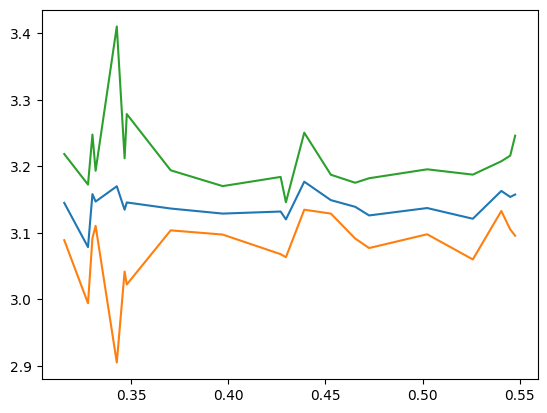

In [176]:
plt.plot(phase_info[:,0], phase_info[:,1])
plt.plot(phase_info[:,0], phase_info[:,2])
plt.plot(phase_info[:,0], phase_info[:,3])

# Conclusions
Yeah, there's something here.